## Compare diff. sessions FF_DWI_drift script 

In [2]:
#Home made utilities - These paths lead to bash and python functions
bash_func=r"/home/malberti/wks14/temp/FF_DWI_Drift/script/bash_func"  #path to bash script  add, cwd=bash_func 
python_func = "/home/malberti/wks14/temp/FF_DWI_Drift/script/python_func"
prj_path=r"/home/malberti/wks14/temp/FF_DWI_Drift" # main BIDS path /home/malberti/Unix_Folders/Sweep/Pilot/SW005
"""
SET UP lib. and main flags
---------------------------------------------
DEBUGGING / LOGGING FLAGS
"""
import subprocess
import os
import getpass
from datetime import datetime
import sys
import socket
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation, PillowWriter
import pandas as pd
from time import time
import nibabel as nib
import glob as gl
#import nilearn as nil
import math

## DIPY 
# nifti manipualtion 
from dipy.io.image import load_nifti, save_nifti
from scipy.ndimage import binary_dilation
from dipy.core.gradients import gradient_table
from dipy.io.gradients import read_bvals_bvecs

from dipy.sims.voxel import multi_tensor
from dipy.core.sphere import disperse_charges, HemiSphere
from dipy.data import get_fnames, small_sphere
from dipy.reconst.csdeconv import auto_response_ssst

# Model fitting 
import dipy.reconst.fwdti as fwdti
import dipy.reconst.dki as dki
import dipy.reconst.msdki as msdki ## I've never implemented this model because there are not enough info from litterature 
from dipy.reconst.dki_micro import axonal_water_fraction
import dipy.reconst.dki_micro as dki_micro
from dipy.reconst.ivim import IvimModel

sys.path.append(python_func)

#from EDDY_RMS import do_EDDY_RMS, do_RMS_movement_plots
from Personalized_mask import do_personalized_mask
#from  RMS_movement_plots import do_RMS_movement_plots
from Supervised_mode import do_supervised_mode
from Tensor_plot import do_tensor_plot
from HomeMadeSlicesDir import do_HomeMadeSlicesDir 


## AMICO (Noddi) -- Settings are based on SK's noddi code
#import amico
#amico.setup()
#ae = amico.Evaluation()
#ae.set_config('doComputeNRMSE', True) #'doDebiasSignal', True)              #'doSaveModulatedMaps', True)

subprocess.run(f'clear')
do_log = 1  # Print log file after each step. Checks if the output is there.
do_debug=1 #enable supervised mode and open each output on fsleyes


In [ ]:
vps = [0, 1]
sessions=["ses-01", "ses-02", "ses-03","ses-04"]
METRICS = {
    "Tensor":   ["FA", "MD"],
    "Kurtosis": ["MK", "kMD", "kFA"],
    "NODDI":    ["NDI", "ODI", "FWF"],
    "FreeWater":["fw", "fwMD", "fwFA"]
} #These are the metric that the script can estimate - In future i will add more 


for vp in vps:
    id = f"sub-{vp:02d}"   # id: standard subject ID (sub-XX)

    for session in sessions:    # Loop over sessions for this participant
        subjid = f"{id}_{session}"     # Standardized subject-session identifier 
        derivatives = os.path.join(prj_path, "derivatives", id, session)   # Path to derivative folder for this participant & session

        Dwmri_index=os.path.join(derivatives, "dwi","index")
        Dtifit_out=os.path.join(Dwmri_index,"Tensor")
        MD_maps=os.path.join(Dtifit_out, str(subjid)+"_prep_MD.nii.gz")

        eddy_path=os.path.join(derivatives, "dwi","eddy")
        mask=os.path.join(eddy_path,f"{subjid}_unwarped_mask.nii.gz")  #The mask is: sub-001_ses-01_
        


/tmp/ipykernel_656360/2028146037.py:82: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=sessions, showfliers=True)


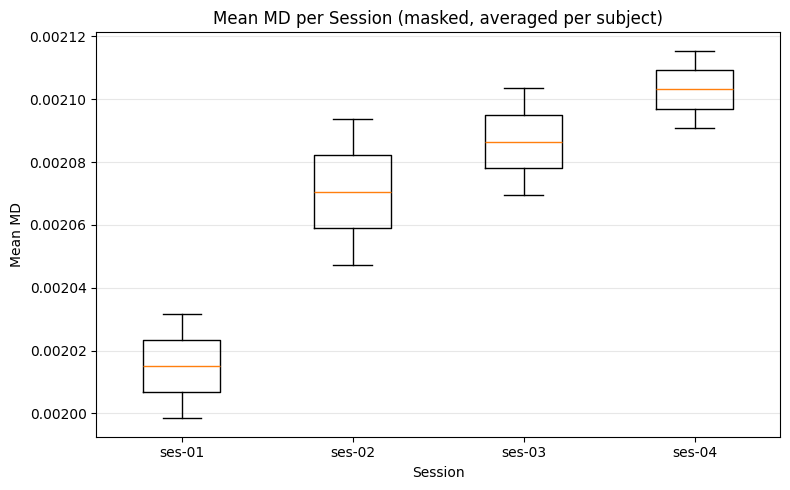

In [3]:
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

# -----------------------
# INPUTS
# -----------------------

vps = [0, 1]
sessions = ["ses-01", "ses-02", "ses-03", "ses-04"]

# -----------------------
# CONTAINER FOR RESULTS
# one list per session
# -----------------------
md_values_per_session = {ses: [] for ses in sessions}

# -----------------------
# LOOP OVER SUBJECTS AND SESSIONS
# -----------------------
for vp in vps:
    id = f"sub-{vp:02d}"

    for session in sessions:
        subjid = f"{id}_{session}"
        derivatives = os.path.join(prj_path, "derivatives", id, session)

        # Paths
        dwi_index = os.path.join(derivatives, "dwi", "index")
        tensor_dir = os.path.join(dwi_index, "Tensor")

        md_map_path = os.path.join(
            tensor_dir, f"{subjid}_prep_MD.nii.gz"
        )

        eddy_path = os.path.join(derivatives, "dwi", "eddy")
        mask_path = os.path.join(
            eddy_path, f"{subjid}_unwarped_mask.nii.gz"
        )

        # -----------------------
        # CHECK FILES EXIST
        # -----------------------
        if not os.path.exists(md_map_path):
            print(f"Missing MD map: {md_map_path}")
            continue

        if not os.path.exists(mask_path):
            print(f"Missing mask: {mask_path}")
            continue

        # -----------------------
        # LOAD DATA
        # -----------------------
        md_img = nib.load(md_map_path).get_fdata()
        mask_img = nib.load(mask_path).get_fdata()

        # -----------------------
        # APPLY MASK
        # -----------------------
        md_masked = md_img[mask_img > 0]

        # Remove NaNs / infs just in case
        md_masked = md_masked[np.isfinite(md_masked)]

        # -----------------------
        # COMPUTE MEAN MD
        # -----------------------
        if md_masked.size > 0:
            mean_md = np.mean(md_masked)
            md_values_per_session[session].append(mean_md)
        else:
            print(f"Empty mask for {subjid}")

# -----------------------
# PLOT BOXPLOT
# -----------------------
data_to_plot = [md_values_per_session[ses] for ses in sessions]

plt.figure(figsize=(8, 5))
plt.boxplot(data_to_plot, labels=sessions, showfliers=True)
plt.ylabel("Mean MD")
plt.xlabel("Session")
plt.title("Mean MD per Session (masked, averaged per subject)")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()
